In [1]:
%matplotlib widget

In [2]:
# Test Forward

In [33]:
# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

In [39]:
sl = '4' # sys.argv[1]
co = '1' #sys.argv[2]
cr = 'c' #sys.argv[3]

In [40]:
# 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# 1. Load model

model = np.load('models/model_s'+sl+'_c'+co+'_u'+cr+'.npy')
npos = np.shape(model)[0]      # number of positions
nlay = np.shape(model)[1] - 2  # number of layers

depths = np.zeros((npos, nlay))
depths[:,1] = - model[:,0]
depths[:,2] = - model[:,0] - model[:,1]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

# mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = [20/1000, 20/100, sig_3d[0]],
                         center = [20,0,height],
                         mapping='Conductivity',
                         domain = ([-20, 60],[-10, 10],[-6,6]),
                         min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                         center_on_edge=False,
                         stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                         lambda_from_center=True,
                         lambda_factor=3, 
                   #      cell_numbers=[512, 128, 128]
                   #      max_buffer = 300000,
                   #      min_width_pps = 5
                         )

# 3. Populate mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

In [41]:
mesh

TensorMesh: 9,437,184 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    512   -103,656.55    127,773.95      0.20 24,077.40    1.23
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z    192       -295.40    116,085.55      0.10 27,680.58    1.31

In [42]:
# Fill before position 0

x = mesh.cell_centers[:,0] <=0
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) & (mesh.cell_centers[:,2] > depths[0,2])
z_lay3 = (mesh.cell_centers[:,2] < depths[0,2])

sig_x[x*y*z_lay1] = model[0,2] # First layer sigma
sig_x[x*y*z_lay2] = model[0,3] # Second layer sigma
sig_x[x*y*z_lay3] = model[0,4]

for p in range(npos):
   
    x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) & (mesh.cell_centers[:,2] > depths[p,2])
    z_lay3 = (mesh.cell_centers[:,2] < depths[p,2])

    sig_x[x*y*z_lay1] = model[p,2]
    sig_x[x*y*z_lay2] = model[p,3]
    sig_x[x*y*z_lay3] = model[p,4]

# fill after position npos

x = (mesh.cell_centers[:,0] > npos) 
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) & (mesh.cell_centers[:,2] > depths[-1,2])
z_lay3 = (mesh.cell_centers[:,2] < depths[-1,2])

sig_x[x*y*z_lay1] = model[-1,2]
sig_x[x*y*z_lay2] = model[-1,3]
sig_x[x*y*z_lay3] = model[-1,4]

#  4. Define models

Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

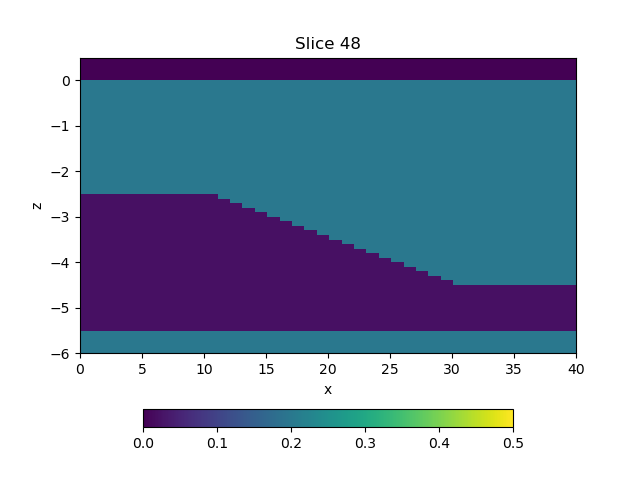

In [55]:
fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model.property_x,
               normal = 'Y',
               v_type='CC',
               clim=[0,.5],
               ax=ax,
             #  grid=True)
                    )
ax.set_xlim([0,40])
ax.set_ylim([-6,0.5])
#ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
#ax.scatter(rec_coords[0], rec_coords[1]+height, c='y')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05)

In [57]:
# 5. Simulate data

# xsrc is a vector of the source position, this source position makes
# the middle point start at 0 and end at 40
# 4 positions before and 3 positions after have no coverage
xsrc = np.linspace(-4, 39, 39+5, endpoint=True) 

#OUT = pd.DataFrame({})

startTime = time.time()
#for p in range(len(xsrc)):

def Dualem842_3D(xsrc, Model, Model_air, frequency=frequency, height=height):
   # print('Position:', p)
    print('Defining geometry')
    # Define source coordinates
    src_x = xsrc
    Hsrc_coords = [src_x, 0, height, 0, 90]
    Vsrc_coords = [src_x, 0, height, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([src_x+2, src_x+4, src_x+8])
    #print('offsets:',offsets_HV)
    #rec_coords = [offsets_HV, offsets_HV*0, np.ones_like(offsets_HV)*height, azi, dip]
    
    # Define P receivers coordinates
    offsets_P = np.array([src_x+2.1, src_x+4.1, src_x+8.1])
    #rec_coords_p = [offsets_P, offsets_P*0, np.ones_like(offsets_P)*height, azi, dip]
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsrc_coords)
    Vsource = emg3d.TxMagneticPoint(Vsrc_coords)
    
    # Solve Electrical fields
    #print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = Model, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = Model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = Model, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = Model_air, source = Vsource, frequency = frequency)

    # Get magnetic fields
   # print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = Model, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = Model, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_V_p)
    
    # Get fields at receivers
  #  print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0)
    
     # Calculate output components OP and IP
 #   print('getting output components')
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
    OUT_i = pd.DataFrame({'geom'  : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
                          'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
                                     Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
                                     Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
                          'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
                          'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
                                               Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
                                               Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
                          'op'    : np.hstack((op_h, op_v, op_p)),
                          'ip'    : np.hstack((ip_h, ip_v, ip_p)) 
                          })
    
    #OUT = pd.concat([OUT, OUT_i], ignore_index=True)
    print()
    return OUT_i
                 
#OUT = Parallel(n_jobs=n_workers,verbose=0)(delayed(Dualem842_3D)(xsrc[p], 
#                Model, Model_air) for p in range(len(xsrc)))

In [59]:
%%time

Dualem842_3D(xsrc[0], Model, Model_air)

Defining geometry
source: [-4.0, 0, 0.15, 0, 90]

CPU times: user 1h 3min 8s, sys: 56.9 s, total: 1h 4min 5s
Wall time: 1h 4min 44s


,geom,src_x,rec_x,midpx,op,ip
0,H2,-4.0,-2.0,-3.00,0.009708,0.001364
1,H4,-4.0,0.0,-2.00,0.027662,0.009317
2,H8,-4.0,4.0,0.00,0.059624,0.054723
3,V2,-4.0,-2.0,-3.00,0.009980,0.000747
4,V4,-4.0,0.0,-2.00,0.036832,0.005420
5,V8,-4.0,4.0,0.00,0.115095,0.035318
6,P2,-4.0,-1.9,-2.95,0.012582,0.000338
7,P4,-4.0,0.1,-1.95,0.045540,0.003355
8,P8,-4.0,4.1,0.05,0.145058,0.030709
